1. CÁC THƯ  VIỆN CẦN THẾT


In [ ]:
!pip install pmdarima kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from pmdarima import auto_arima
import warnings
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os
print("--- Đang kiểm tra và cài đặt thư viện... ---")
try:
    import pmdarima
    import kagglehub
except ImportError:
    os.system('pip install pmdarima kagglehub')
    print("Đã cài đặt xong pmdarima và kagglehub!")
# Tắt các cảnh báo không cần thiết
warnings.filterwarnings("ignore")

--- Đang kiểm tra và cài đặt thư viện... ---


2. LẤY DỮ LIỆU

In [ ]:
print("\n--- Đang tải dữ liệu từ Kaggle ... ---")
# Tải bộ dữ liệu về máy Colab
path = kagglehub.dataset_download("andrewmvd/sp-500-stocks")

# Tạo đường dẫn chính xác đến file CSV
csv_file = os.path.join(path, "sp500_stocks.csv")

print(f"Đọc file từ: {csv_file}")
# Đọc file CSV
df_raw = pd.read_csv(csv_file)



--- Đang tải dữ liệu từ Kaggle ... ---
Using Colab cache for faster access to the 'sp-500-stocks' dataset.
Đọc file từ: /kaggle/input/sp-500-stocks/sp500_stocks.csv


3. Xử lý dữ liệu

In [ ]:
TARGET_STOCK = 'GOOG'
print(f"\n--- Đang xử lý dữ liệu cho mã: {TARGET_STOCK} ---")

# Lọc lấy mã GOOG
df = df_raw[df_raw['Symbol'] == TARGET_STOCK].copy()

# Chuyển cột Date sang dạng thời gian
df['Date'] = pd.to_datetime(df['Date'])

# Sắp xếp theo ngày và đặt làm Index
df = df.sort_values('Date').set_index('Date')

# Lấy cột giá đóng cửa (Close)
data = df[['Close']].dropna()
# Lấy logarit để ổn định phương sai
data_log = np.log(data['Close'])
print(f"Dữ liệu sau khi xử lý: {data.shape[0]} dòng.")


--- Đang xử lý dữ liệu cho mã: GOOG ---
Dữ liệu sau khi xử lý: 3768 dòng.


4. CHẠY MÔ HÌNH ARIMA

In [ ]:
# Chia tập train/test (80/20)
train_size = int(len(data_log) * 0.8)
train_log, test_log = data_log[0:train_size], data_log[train_size:]

print(f"Kích thước tập Train: {len(train_log)}")
print(f"Kích thước tập Test: {len(test_log)}")

print("\n--- Đang tìm tham số tối ưu (Auto ARIMA)... ---")
# Tìm bộ tham số tốt nhất
model_auto = auto_arima(train_log,
                        start_p=1, start_q=1,
                        max_p=3, max_q=3, # Giới hạn p,q nhỏ để tránh quá khớp
                        m=1,
                        d=None,
                        seasonal=False,
                        trace=True,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True)

print(f"\nTham số tốt nhất tìm được: {model_auto.order}")

# Huấn luyện mô hình
print("--- Đang huấn luyện và dự báo... ---")
model = ARIMA(train_log, order=model_auto.order)
model_fit = model.fit()

# Dự báo và đảo ngược log
print("\n--- Đang thực hiện dự đoán... ---")
forecast_result = model_fit.get_forecast(steps=len(test_log))
forecast_log = forecast_result.predicted_mean
conf_int_log = forecast_result.conf_int()

# --- CHUYỂN ĐỔI NGƯỢC TỪ LOG VỀ GIÁ TIỀN (EXP) ---
forecast_values = np.exp(forecast_log)
lower_series = np.exp(conf_int_log.iloc[:, 0])
upper_series = np.exp(conf_int_log.iloc[:, 1])

# Lấy dữ liệu thực tế (đã đảo ngược log) để so sánh
y_true = np.exp(test_log)
y_train_true = np.exp(train_log)

Kích thước tập Train: 3014
Kích thước tập Test: 754

--- Đang tìm tham số tối ưu (Auto ARIMA)... ---
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-16285.447, Time=0.56 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-16281.802, Time=0.31 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-16286.817, Time=0.22 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-16286.619, Time=1.99 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-16277.571, Time=0.56 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-16285.345, Time=1.52 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-16282.313, Time=1.19 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-16281.972, Time=0.14 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 6.525 seconds

Tham số tốt nhất tìm được: (1, 1, 0)
--- Đang huấn luyện và dự báo... ---

--- Đang thực hiện dự đoán... ---


5. ĐÁNH GIÁ MÔ HÌNH

In [ ]:
# Chuyển về dạng numpy array để tránh lỗi lệch index khi tính toán
y_true_vals = y_true.values
forecast_vals = forecast_values.values

mse = mean_squared_error(y_true_vals, forecast_vals)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_vals, forecast_vals)

# Tính MAPE: (Thực tế - Dự báo) / Thực tế
# Thêm kiểm tra mẫu số khác 0 để tránh lỗi chia cho 0
mape = np.mean(np.abs((y_true_vals - forecast_vals) / y_true_vals)) * 100

print("\n------------------------------------------------")
print(f"KẾT QUẢ ĐÁNH GIÁ ({TARGET_STOCK}):")
print(f"1. RMSE (Sai số chuẩn): {rmse:.2f}")
print(f"2. MAE (Sai số tuyệt đối): {mae:.2f}")
print(f"3. MAPE (Sai số phần trăm): {mape:.2f}%")
print("------------------------------------------------")



------------------------------------------------
KẾT QUẢ ĐÁNH GIÁ (GOOG):
1. RMSE (Sai số chuẩn): 29.34
2. MAE (Sai số tuyệt đối): 24.81
3. MAPE (Sai số phần trăm): 20.88%
------------------------------------------------


6. TRỰC QUAN HOÁ KẾT QUẢ

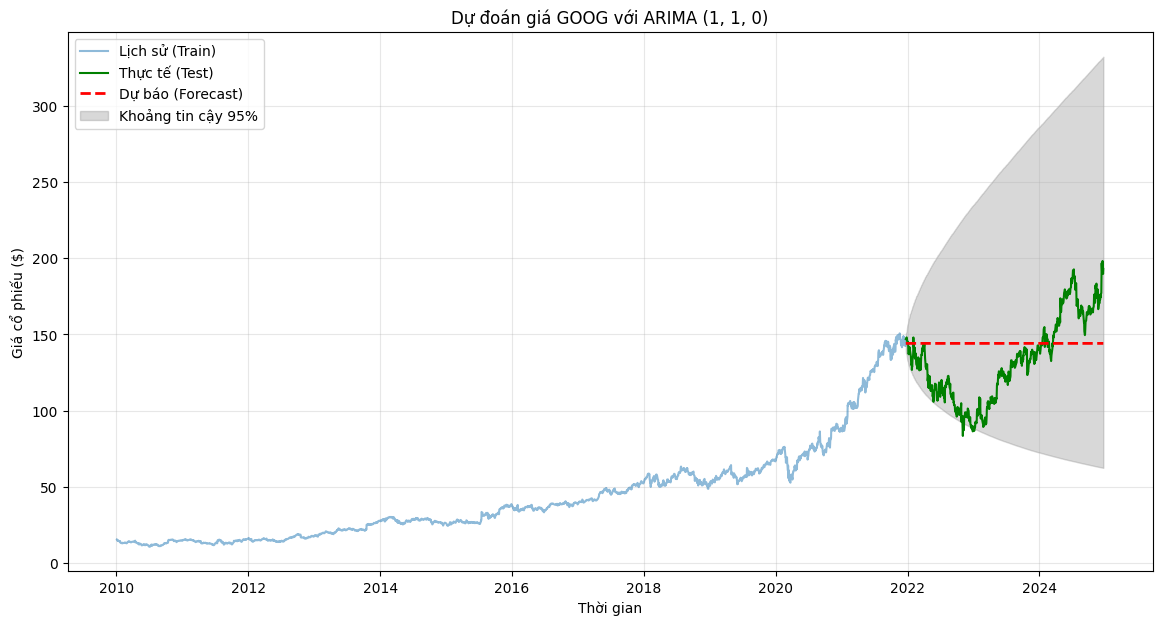

In [ ]:
plt.figure(figsize=(14, 7))

# Vẽ dữ liệu thực tế (Train & Test)
plt.plot(y_train_true.index, y_train_true, label='Lịch sử (Train)', alpha=0.5)
plt.plot(y_true.index, y_true, label='Thực tế (Test)', color='green')

# Vẽ dự báo (Gán index của y_true để khớp trục thời gian)
# Lưu ý: forecast_values có thể bị lệch index do statsmodels tự sinh,
# nên ta vẽ theo trục y_true.index cho an toàn
plt.plot(y_true.index, forecast_values.values, label='Dự báo (Forecast)', color='red', linestyle='--', linewidth=2)

# Vẽ khoảng tin cậy
# Cần đảm bảo lower/upper series cũng khớp độ dài
plt.fill_between(y_true.index,
                 lower_series.values,
                 upper_series.values,
                 color='gray', alpha=0.3, label='Khoảng tin cậy 95%')

plt.title(f'Dự đoán giá {TARGET_STOCK} với ARIMA {model_auto.order}')
plt.xlabel('Thời gian')
plt.ylabel('Giá cổ phiếu ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

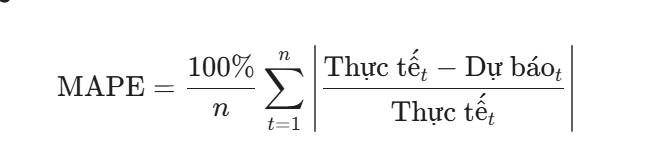

Trong đó:
* Thực tế: Giá trị thực tế của dữ liệu (ví dụ: giá cổ phiếu thực tế).
* Dự báo: Giá trị mà mô hình dự đoán.
* n: Số lượng mẫu dữ liệu.
* Ý nghĩa: MAPE cho biết sai số trung bình của mô hình tính theo phần trăm (%).
Ví dụ: MAPE = 20% nghĩa là dự báo của mô hình lệch trung bình khoảng 20% so với thực tế.Giá trị càng thấp càng tốt: MAPE càng nhỏ chứng tỏ mô hình dự báo càng chính xác.


In [ ]:
if 'df_raw' not in locals():
    print("Đang tải lại dữ liệu gốc...")
    path = kagglehub.dataset_download("andrewmvd/sp-500-stocks")
    csv_file = os.path.join(path, "sp500_stocks.csv")
    df_raw = pd.read_csv(csv_file)
#Drop dữ liệu nan
df_raw = df_raw.dropna()
# Gán lại df bằng dữ liệu đầy đủ
df = df_raw.copy()

# 3. CHUẨN BỊ VÒNG LẶP
df['Symbol'] = df['Symbol'].str.strip()
all_tickers = df['Symbol'].unique()

# Danh sách lưu trữ điểm số
list_rmse, list_mae, list_mape = [], [], []
processed_tickers = []
print(f"--- Bắt đầu chấm điểm mô hình ARIMA trên danh mục (Tổng: {len(all_tickers)} mã) ---")

# Chạy thử nghiệm 30 mã đầu
for ticker in all_tickers[:30]:
    try:
        # Lấy dữ liệu
        ticker_df = df[df['Symbol'] == ticker].sort_values('Date')

        if len(ticker_df) < 200: # Chỉ lấy mã có đủ dữ liệu lịch sử
            continue

        data_values = ticker_df['Close'].values

        # 1. LOG TRANSFORM (Bước quan trọng bị thiếu ở version cũ)
        # Thêm 1e-6 để tránh log(0) nếu có giá = 0
        data_log = np.log(data_values + 1e-6)

        # Chia train/test
        train_size = int(len(data_log) * 0.8)
        train_data_log = data_log[:train_size]
        test_data_actual = data_values[train_size:]

        # --- HUẤN LUYỆN ARIMA ---
        # start_p, start_q... nhỏ để chạy nhanh
       # Tăng max_p/q lên 3 hoặc 4 để mô hình linh hoạt hơn
        model = auto_arima(train_data_log,
                           start_p=1, start_q=1,
                           max_p=4, max_q=4,
                           m=1, seasonal=False,
                           trace=False,
                           error_action='ignore',
                           suppress_warnings=True)
        # --- DỰ BÁO ---
        preds_log = model.predict(n_periods=len(test_data_actual))

        # --- Đảo ngược Log ---
        preds_actual = np.exp(preds_log)

        # --- TÍNH ĐIỂM ---
        rmse = np.sqrt(mean_squared_error(test_data_actual, preds_actual))
        mae = mean_absolute_error(test_data_actual, preds_actual)
        mape = mean_absolute_percentage_error(test_data_actual, preds_actual)

        list_rmse.append(rmse)
        list_mae.append(mae)
        list_mape.append(mape)
        processed_tickers.append(ticker)

        print(f"OK | MAPE: {mape*100:.2f}%")

    except Exception as e:
        print(f"Lỗi tại {ticker}: {e}")
        continue

# 4. TỔNG KẾT
if list_mape:
    final_mape = np.mean(list_mape) * 100
    print("\n" + "="*40)
    print(f"KẾT QUẢ TRUNG BÌNH ({len(list_mape)} mã)")
    print(f"MAPE: {final_mape:.2f}%")
    print("="*40)

    if final_mape < 5:
        print("Đánh giá: Mô hình cực kỳ chính xác (Excellent).")
    elif final_mape < 15:
        print("Đánh giá: Mô hình có độ chính xác tốt (Good)")
    else:
        print("Đánh giá:Mô hình cần được tối ưu thêm (Poor).")

--- Bắt đầu chấm điểm mô hình ARIMA trên danh mục (Tổng: 172 mã) ---
OK | MAPE: 56.93%
OK | MAPE: 54.09%
OK | MAPE: 8.93%
OK | MAPE: 23.89%
OK | MAPE: 49.23%
OK | MAPE: 23.51%
OK | MAPE: 11.38%
OK | MAPE: 47.83%
OK | MAPE: 8.64%
OK | MAPE: 87.15%
OK | MAPE: 14.38%
OK | MAPE: 11.74%
OK | MAPE: 20.04%
OK | MAPE: 76.22%
OK | MAPE: 16.90%
OK | MAPE: 26.66%
OK | MAPE: 5.21%
OK | MAPE: 10.15%
OK | MAPE: 26.86%
OK | MAPE: 24.34%
OK | MAPE: 86.85%
OK | MAPE: 17.37%
OK | MAPE: 22.56%
OK | MAPE: 21.77%
OK | MAPE: 11.42%
OK | MAPE: 12.03%
OK | MAPE: 19.54%
OK | MAPE: 24.37%
OK | MAPE: 23.95%
OK | MAPE: 123.31%

KẾT QUẢ TRUNG BÌNH (30 mã)
MAPE: 32.24%
Đánh giá:Mô hình cần được tối ưu thêm (Poor).
